#  Introduction to Single-Cell RNA-seq Analysis

This notebook is designed as a first end-to-end learning experience in single-cell RNA-seq (scRNA-seq).

It is structured as an intuitive lesson rather than a pipeline.

At every stage we explicitly ask:
- What does the data look like?
- What changed?
- Why does this matter biologically?
- What should I visually notice?
- What questions should I be able to answer before moving on?


---
# 1. Setup
---

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sc.settings.verbosity = 2
sc.set_figure_params(dpi=80)


##  What is Scanpy?

Scanpy is a Python library built specifically for analyzing single-cell RNA-seq data.


### Why this matters

Instead of passing many separate objects between functions, Scanpy keeps everything in one structured container. This makes analysis reproducible and inspectable at every step.

---

## Scanpy function structure

- sc.pp → preprocessing (changes data)
- sc.tl → tools (computes results)
- sc.pl → plotting (visualization)

You should always ask: is this modifying data, computing structure, or visualizing?


# 2. Load Data

## Where does this data come from?

This dataset comes from 10x Genomics single-cell RNA sequencing of human peripheral blood mononuclear cells (PBMCs).

PBMCs include immune cells such as:
- T cells (adaptive immunity)
- B cells (antibody-producing cells)
- Monocytes (innate immune system)
- NK cells (cytotoxic immune response)

### Why this dataset is used

We use PBMC3k because:
- It is real experimental data
- It is small and fast to analyze
- It contains well-known immune populations
- It is widely used as a teaching benchmark

This is not simulated data.


In [2]:
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

# 3. Inspect Raw Data

Scanpy revolves around a central data structure called AnnData, which stores:

- Gene expression matrix (cells × genes)
- Cell metadata (.obs)
- Gene metadata (.var)
- Computed results (.obsm, .uns)


In [3]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [4]:
adata.shape

(2700, 32738)

In [5]:
adata.X[:5, :5]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 0 stored elements and shape (5, 5)>

In [6]:
adata.obs.head()

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


In [7]:
adata.var.head()

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945


## What are we looking at?

- Rows = cells
- Columns = genes
- Values = raw RNA counts

At this stage:
- Data is extremely sparse
- No biological structure is visible yet
- Technical noise dominates


# 4. Quality Control (QC)

Before analyzing the data, we need to identify and remove low-quality cells.

## What makes a cell low-quality?

**Low gene count** (`n_genes_by_counts`)
Cells that express very few genes are likely empty droplets or debris captured during sequencing — not real cells.

**High mitochondrial fraction** (`pct_counts_mt`)
Mitochondrial genes (prefixed `MT-`) encode proteins for cellular respiration. When a cell is dying or damaged, cytoplasmic RNA is lost first while mitochondrial RNA is retained — so a high MT fraction signals cell stress or death.

## What to look for in the scatter plots

- Most cells should cluster in a "healthy" band: moderate total counts and low MT fraction
- Outliers with very high MT % (dying cells) or very low gene counts (empty droplets) should be clearly visible
- Cells with extremely high total counts may be doublets — two cells captured in one droplet

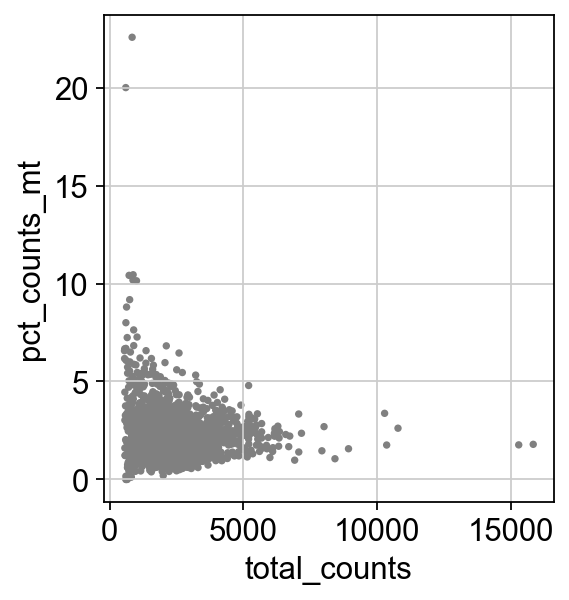

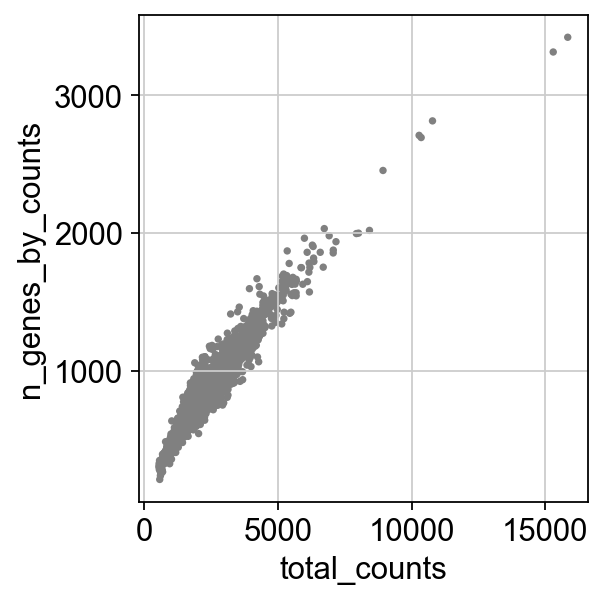

In [8]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

# 5. Filtering Cells

We remove cells that fall outside acceptable QC thresholds.

## Why these thresholds?

- `n_genes_by_counts > 200` — removes empty droplets and debris, which typically express almost nothing
- `pct_counts_mt < 5%` — removes dying cells; 5% is a common starting point for PBMCs but may need adjustment per dataset

These are heuristic cutoffs, not biological law. The scatter plots from Section 4 should inform whether your thresholds are capturing true outliers or trimming real cells.

Here we go from 2700 → 2643 cells — a small reduction, which suggests this dataset is already relatively high quality.

In [9]:
adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]
adata.shape

(2643, 32738)

# 6. Normalization

Raw counts are not directly comparable across cells. A cell with 5,000 total counts and one with 500 will look very different even if they express the same genes proportionally — because of variable sequencing depth, not biology.

## What we do

1. **`normalize_total`** — scales each cell so its total count equals 10,000 (a standard convention). Gene expression is now proportional and comparable across cells.
2. **`log1p`** — applies log(x + 1) to all values. This compresses the wide dynamic range of RNA counts (which can span several orders of magnitude), making the distribution more normal and preventing highly expressed genes from dominating downstream analysis.

After normalization, we immediately save a copy of `adata` before any further transformations. This copy (`adata_ct`) will be used for cell type annotation in Section 11, which requires log-normalized expression across all genes — not the scaled, HVG-subset form `adata` will become.

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell


/var/folders/2f/bl3gx3l16fzcbmxhlpqqxr8c0000gn/T/ipykernel_84197/3052528762.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


    finished (0:00:01)


In [11]:
# Save here — after normalization, before HVG subsetting and scaling.
# CellTypist requires log-normalized expression across all genes;
# it cannot accept the scaled, HVG-filtered form that adata will become.
adata_ct = adata.copy()

# 7. Highly Variable Genes (HVG)

Not all 32,738 genes are informative. Many are expressed at roughly the same level across all cells — housekeeping genes that contribute noise rather than signal. We retain only genes that vary meaningfully across cells, since these are most likely to distinguish cell types or states.

Scanpy selects the top ~2,000 most variable genes by default and flags them in `adata.var.highly_variable`. We then subset `adata` to these genes, dramatically reducing dimensionality before PCA while focusing analysis on biologically informative variation.

In [12]:
sc.pp.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable]

extracting highly variable genes
    finished (0:00:01)


# 8. PCA

Even after HVG selection, we still have ~2,000 dimensions. PCA (Principal Component Analysis) compresses this into a smaller set of components ordered by how much variance they capture.

## Steps

- **`scale`** — zero-centers each gene and clips values at 10. This prevents genes with large absolute expression values from dominating PCA.
- **`pca`** — computes the principal components
- **Variance ratio plot** — shows how much each PC contributes. Look for an "elbow" where the curve flattens; PCs beyond that point add little new information. We use 40 PCs downstream, which is conservative but safe for this dataset.

computing PCA
    with n_comps=50


/Users/gavinoliver/.local/share/uv/python/cpython-3.14.3-macos-aarch64-none/lib/python3.14/functools.py:982: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/gavinoliver/.local/share/uv/python/cpython-3.14.3-macos-aarch64-none/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:01)


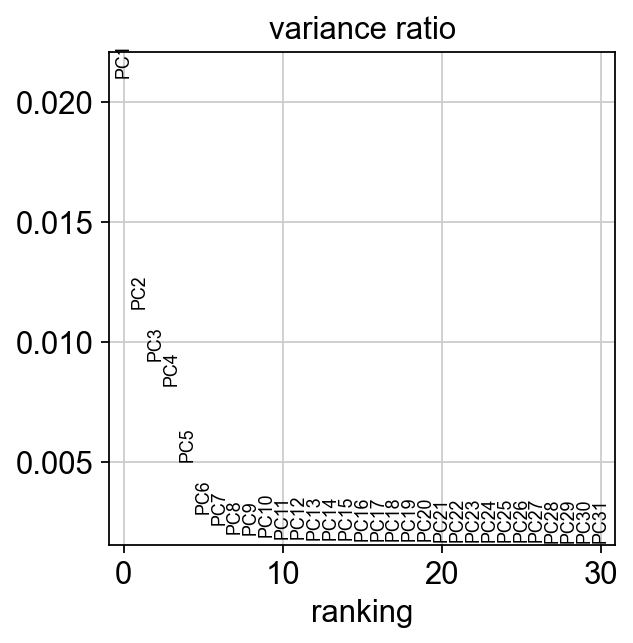

In [13]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata)

# 9. Neighborhood Graph + UMAP

PCA gives us a compact representation, but it is still linear and high-dimensional. UMAP projects this into 2D for visualization while attempting to preserve local cell-cell relationships.

## Steps

- **`neighbors`** — builds a k-nearest neighbor (kNN) graph in PCA space. Each cell is connected to its 10 most similar neighbors. This graph encodes the local structure of the data.
- **`umap`** — lays out the kNN graph in 2D. Cells that are transcriptionally similar (many shared neighbors) will appear close together.

UMAP is a visualization tool. The distances between clusters are not quantitatively meaningful, but the presence of distinct groups and their relative topology reflect real biological structure.

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished (0:00:07)
computing UMAP
    finished (0:00:03)


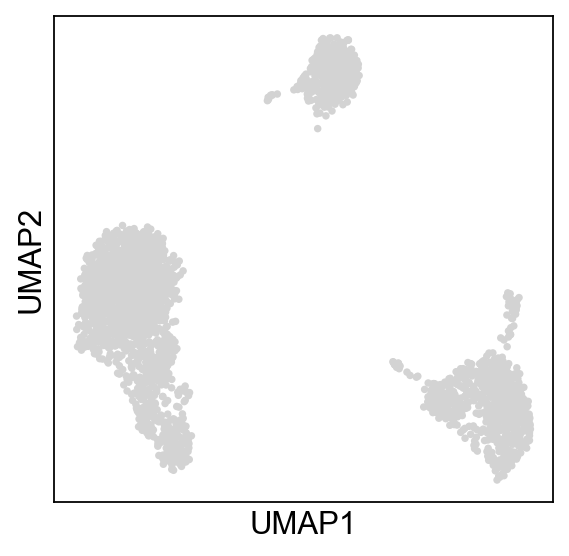

In [14]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata)

# 10. Clustering (Leiden)

We now detect communities in the kNN graph — groups of cells that are more connected to each other than to the rest of the data.

Leiden is a graph partitioning algorithm that identifies these communities by optimizing a modularity score. The `resolution` parameter controls granularity: higher values produce more, smaller clusters; lower values produce fewer, broader ones. We use the default here. In practice, you would tune this based on biological expectations (e.g., do you expect 5 major cell types or 20 subtypes?).

Clusters at this stage are defined purely by transcriptional similarity — they carry no biological labels yet. That comes in the next section.

running Leiden clustering


/var/folders/2f/bl3gx3l16fzcbmxhlpqqxr8c0000gn/T/ipykernel_84197/3332512261.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


    finished (0:00:00)


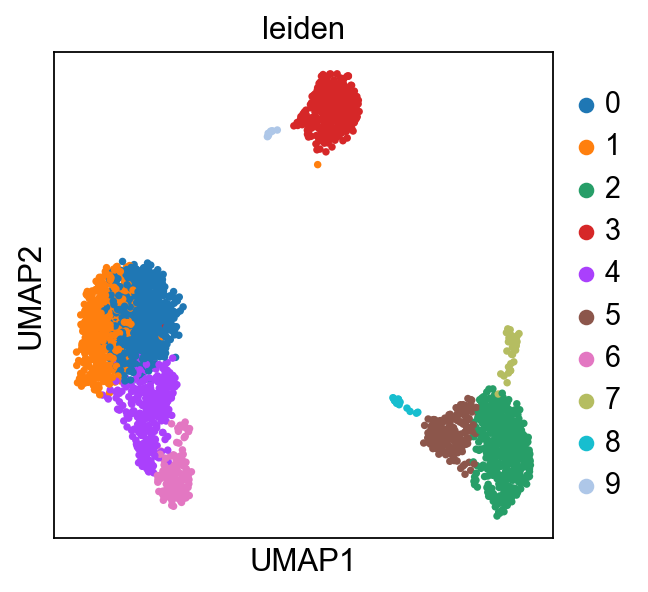

In [15]:
sc.tl.leiden(adata)
sc.pl.umap(adata, color='leiden')

# 11. Marker Genes + Cell Typing

Leiden clusters are unlabeled — groups of transcriptionally similar cells with no biological identity yet. We assign meaning using two approaches.

## Unsupervised: rank_genes_groups

For each cluster, finds genes that are significantly more expressed than in all other cells combined. These marker genes can be cross-referenced against known signatures (e.g., CD3D → T cells, LYZ → monocytes) to manually identify cell types.

## Supervised: CellTypist

A pre-trained classifier that maps each cell to a label from a curated immune cell atlas. `majority_voting=True` refines predictions using neighborhood context, smoothing noisy individual-cell calls into more coherent cluster-level labels.

## Why `adata_ct` is used here

CellTypist requires log-normalized expression across all genes — not scaled, not HVG-subset. We saved `adata_ct` in Section 6 immediately after normalization to preserve this format. We reuse the UMAP coordinates and Leiden labels computed from `adata` so both objects share the same embedding without redundant computation.

ranking genes
    finished (0:00:00)


/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:484:

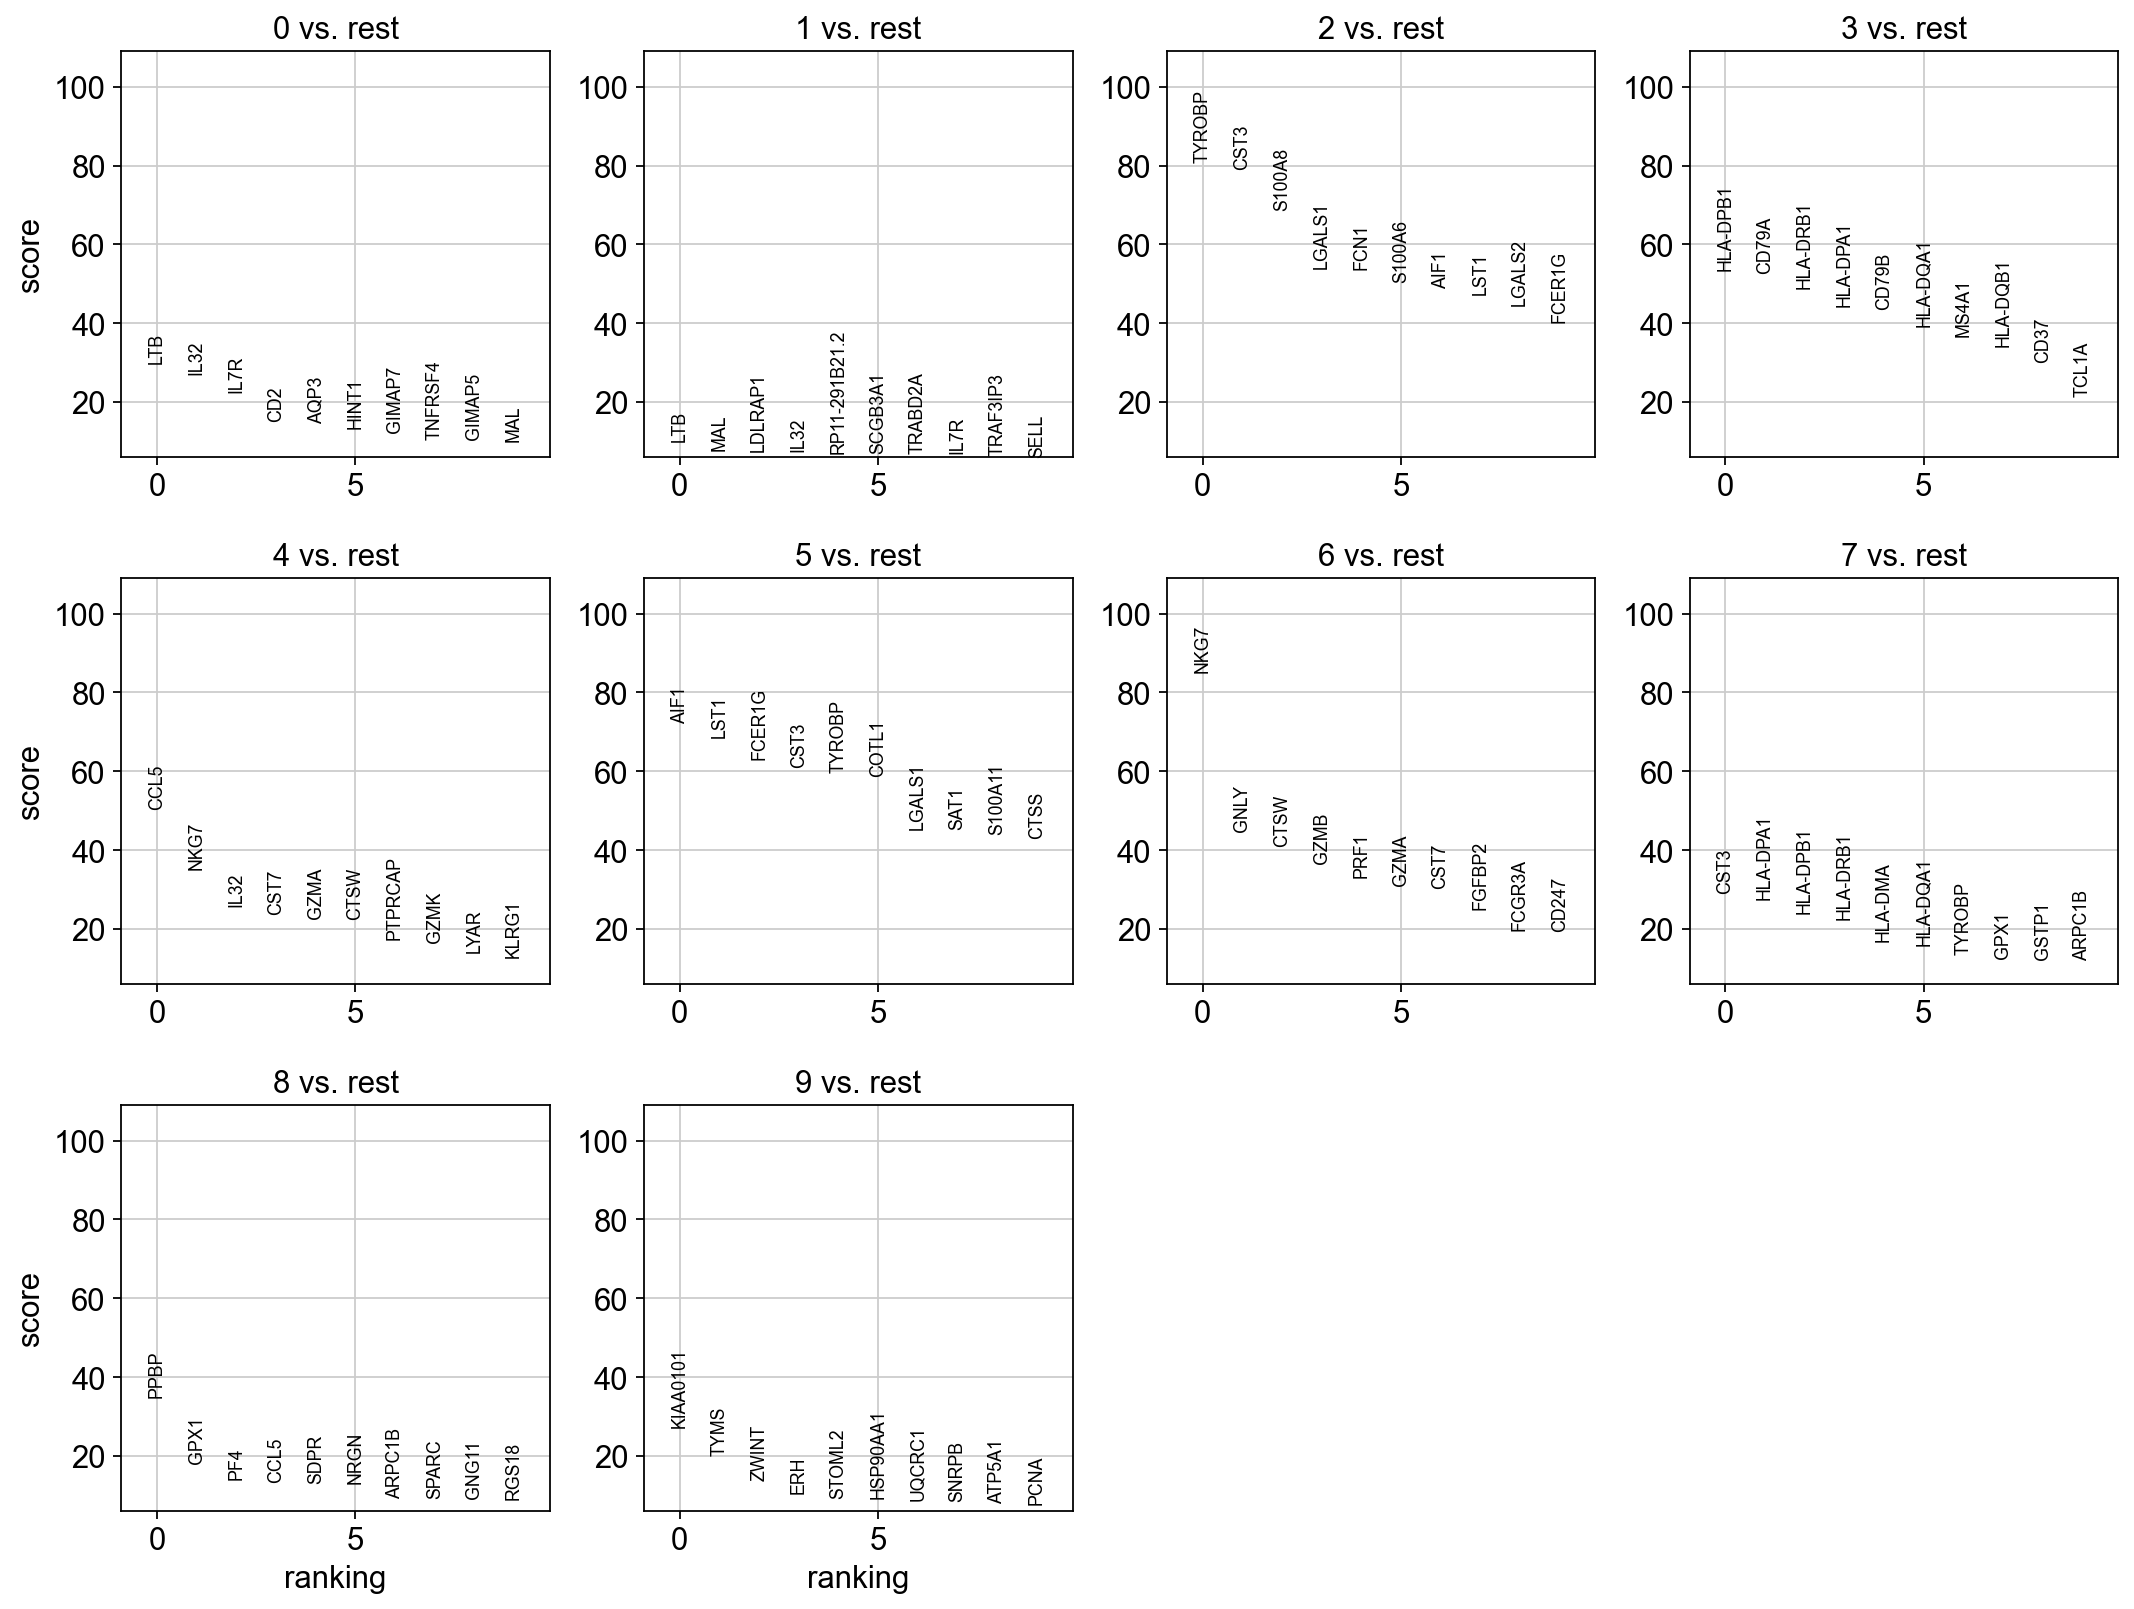

/Users/gavinoliver/git_repos/scrna-basics/.venv/lib/python3.14/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
👉 Detailed model information can be found at `https://www.celltypist.org/models`
🔬 Input data has 2643 cells and 32738 genes
🔗 Matching reference genes in the model
🧬 5278 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering


filtered out 20185 genes that are detected in less than 5 cells
extracting highly variable genes
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:02)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:00)


⛓️ Over-clustering input data with resolution set to 5


running Leiden clustering
    finished (0:00:00)


🗳️ Majority voting the predictions
✅ Majority voting done!


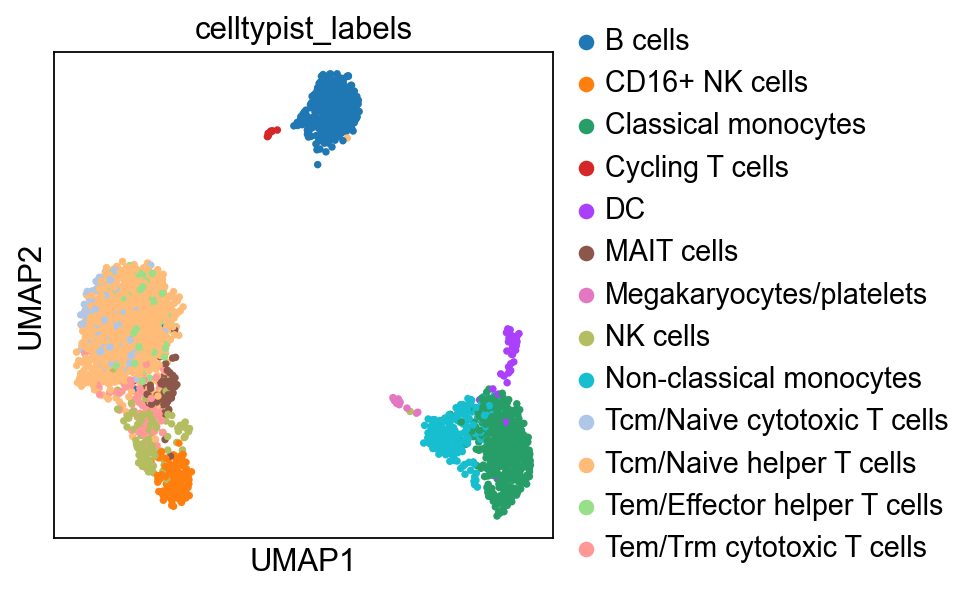

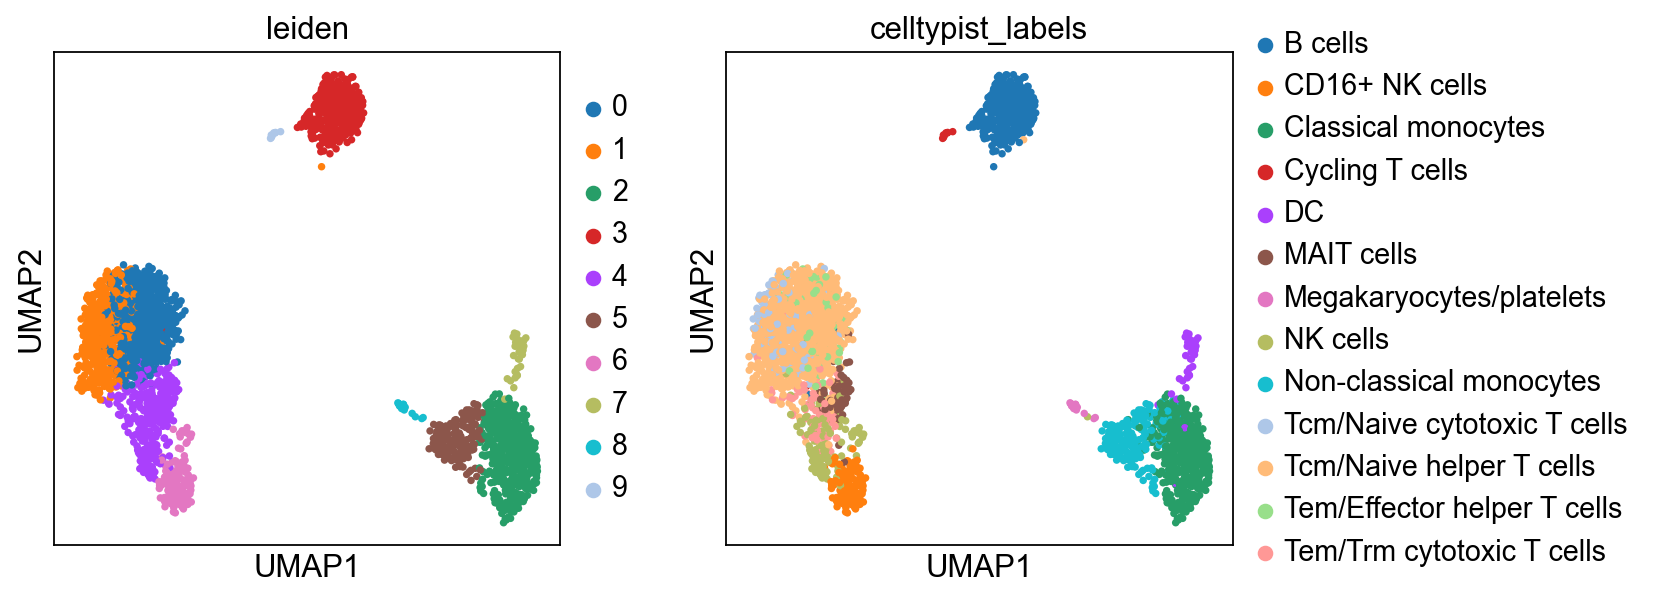

In [16]:
# Identify marker genes per Leiden cluster
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=10)

import celltypist
from celltypist import models

# Optional: view available pretrained reference models
models.models_description()

# Run CellTypist on log-normalized data (adata_ct)
pred = celltypist.annotate(
    adata_ct,
    model='Immune_All_Low.pkl',
    majority_voting=True
)

adata_ct.obs["celltypist_labels"] = pred.predicted_labels["majority_voting"]

# Transfer UMAP and cluster labels from adata.
# adata_ct holds the same cells but with the full gene space CellTypist requires;
# we reuse the embedding computed on the HVG-scaled data rather than recomputing.
adata_ct.obsm["X_umap"] = adata.obsm["X_umap"]
adata_ct.obs["leiden"] = adata.obs["leiden"].values

sc.pl.umap(adata_ct, color='celltypist_labels')
sc.pl.umap(adata_ct, color=['leiden', 'celltypist_labels'])

# 12. Final Summary

We transformed raw sequencing data into biological structure:

1. Raw counts
2. QC filtering
3. Normalization
4. HVG selection
5. PCA
6. UMAP
7. Clustering
8. Marker genes
9. Cell typing

Each step reduces noise and reveals biology.
